In [1]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Data Loading

In [22]:
df = pd.read_csv('./daily.csv')
df = df.dropna()

prices = df['Price'].values

minm, maxm = prices.min(), prices.max()
prices = (prices - minm) / (maxm - minm)
len(prices)
df.head(11), prices

(          Date  Price
 0   1997-01-07   3.82
 1   1997-01-08   3.80
 2   1997-01-09   3.61
 3   1997-01-10   3.92
 4   1997-01-13   4.00
 5   1997-01-14   4.01
 6   1997-01-15   4.34
 7   1997-01-16   4.71
 8   1997-01-17   3.91
 9   1997-01-20   3.26
 10  1997-01-21   2.99,
 array([0.12143797, 0.12056116, 0.11223148, ..., 0.12406839, 0.1245068 ,
        0.13415169], shape=(7093,)))

## Dataset and DataLoader

In [27]:
class MyDataset(Dataset):
    def __init__(self, y, seq_length=10):
        self.seq_length = seq_length
        self.y = y
        self.total_samples = len(y) - seq_length

    def __len__(self):
        return self.total_samples
    
    def __getitem__(self, idx):
        X = self.y[idx : idx + self.seq_length]
        Y = self.y[idx + self.seq_length]
        X = torch.tensor(X, dtype=torch.float32).to(device)
        Y = torch.tensor(Y, dtype=torch.float32).to(device)

        return X, Y
    
torch.manual_seed(42)
dataset = MyDataset(prices)
train, test = torch.utils.data.random_split(dataset, [0.9, 0.1])
batch_size = 1
train_dataloader = DataLoader(train, batch_size, shuffle=True)
test_dataloader = DataLoader(test, batch_size)

len(train_dataloader), len(test_dataloader)

(6375, 708)

## RNN

In [28]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.rnn = nn.RNN(1, 5, 1, batch_first=True)
        self.fc1 = nn.Linear(5, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        output, h_n = self.rnn(x)
        output = output[:, -1, :]
        # output = self.relu(output)
        output = self.fc1(output).reshape(-1)
        return output

model = RNNModel().to(device)
print(model)

RNNModel(
  (rnn): RNN(1, 5, batch_first=True)
  (fc1): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
)


In [30]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 5

## Training

In [31]:
loss_list = []
model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for input, target in train_dataloader:
        optimizer.zero_grad()  # reset grad
        output = model(input.reshape((-1, 10, 1)))  # predict
        batch_loss = criterion(output, target)  # compute loss
        batch_loss.backward()  # compute grad
        optimizer.step()  # update weights

        epoch_loss += batch_loss.item()

    loss = epoch_loss / len(train_dataloader)
    loss_list.append(loss)
    print(f"Ep {epoch}: Loss = {loss}")

Ep 0: Loss = 0.003931210865010818
Ep 1: Loss = 0.0004332930736084259
Ep 2: Loss = 0.00039520014913399553
Ep 3: Loss = 0.00037834664667901166
Ep 4: Loss = 0.0003684923548444452


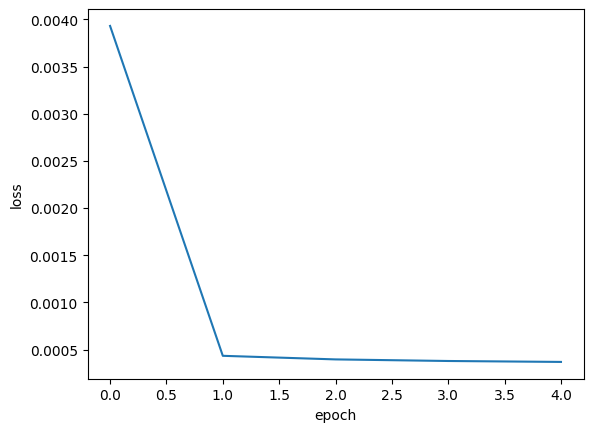

In [34]:
plt.plot(loss_list)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## Testing

In [ ]:
model.eval()
all_pred, all_label = [], []

with torch.no_grad():
    for input, target in test_dataloader:
        input = input.reshape(-1, 10, 1)
        all_pred.append(model(input).item())
        all_label.append(target.item())

len(all_pred), len(all_label)

[tensor([0.0316]),
 tensor([0.0780]),
 tensor([0.2481]),
 tensor([0.2284]),
 tensor([0.0912]),
 tensor([0.0416]),
 tensor([0.1828]),
 tensor([0.1477]),
 tensor([0.1280]),
 tensor([0.2950]),
 tensor([0.2657]),
 tensor([0.1100]),
 tensor([0.1236]),
 tensor([0.0780]),
 tensor([0.0697]),
 tensor([0.2411]),
 tensor([0.2775]),
 tensor([0.1157]),
 tensor([0.0465]),
 tensor([0.3911]),
 tensor([0.0566]),
 tensor([0.0495]),
 tensor([0.1854]),
 tensor([0.1013]),
 tensor([0.0390]),
 tensor([0.1464]),
 tensor([0.1166]),
 tensor([0.1306]),
 tensor([0.0732]),
 tensor([0.1942]),
 tensor([0.0947]),
 tensor([0.2104]),
 tensor([0.1276]),
 tensor([0.2332]),
 tensor([0.0583]),
 tensor([0.2407]),
 tensor([0.2091]),
 tensor([0.1188]),
 tensor([0.0763]),
 tensor([0.0644]),
 tensor([0.1491]),
 tensor([0.1008]),
 tensor([0.2525]),
 tensor([0.0601]),
 tensor([0.0460]),
 tensor([0.1806]),
 tensor([0.1758]),
 tensor([0.3056]),
 tensor([0.0807]),
 tensor([0.4919]),
 tensor([0.1092]),
 tensor([0.0482]),
 tensor([0.0

In [41]:
from sklearn.metrics import mean_squared_error
mean_squared_error(all_label, all_pred)

0.0002107110135269829